In [13]:
import pandas as pd
import numpy as np

# 1. Extração (Pet Shop Online)
dados = {
    'Faturamento': [500, 1200, 300, 800, 1500, 200, 950, 400, 1100, 700],
    'Horas_Gastas': [2, 5, 1, 3, 6, 1, 4, 2, 5, 3],
    'Custo_Hora': [50, 60, np.nan, 55, 65, 50, np.nan, 52, 60, 58],
    'Status': ['Entregue', 'Entregue', 'Atrasado', 'Entregue', 'Entregue',
               'Cancelado', 'Entregue', 'Atrasado', 'Entregue', 'Entregue']
}

df = pd.DataFrame(dados)

# 2. Transformação
df.dropna(subset=['Faturamento', 'Horas_Gastas'], inplace=True)

df['Custo_Hora'] = df['Custo_Hora'].fillna(df['Custo_Hora'].mean())

df['Status'] = df['Status'].str.strip().str.capitalize()

df['Custo_Total'] = df['Horas_Gastas'] * df['Custo_Hora']

# 3. KPIs

faturamento_total = df['Faturamento'].sum()

taxa_sucesso = (df[df['Status'] == 'Entregue'].shape[0] / df.shape[0]) * 100

custo_medio = df['Custo_Total'].mean()

df['Lucro'] = df['Faturamento'] - df['Custo_Total']
margem_media = df['Lucro'].mean()

print(f"Faturamento Total Pet Shop Online: R$ {faturamento_total:,.2f}")
print(f"Taxa de Sucesso dos Pedidos: {taxa_sucesso:.1f}%")
print(f"Custo Médio Operacional: R$ {custo_medio:,.2f}")
print(f"Margem Média: R$ {margem_media:,.2f}")

Faturamento Total Pet Shop Online: R$ 7,650.00
Taxa de Sucesso dos Pedidos: 70.0%
Custo Médio Operacional: R$ 186.43
Margem Média: R$ 578.58


In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Base Pet Shop Online
dados = {
    'Faturamento': [50, 120, 40, 80, 150, 30, 95, 60, 110, 70,
                    200, 45, 130, 90, 55],
    'Horas_Gastas': [1, 2, 1, 1.5, 3, 0.5, 2, 1, 2.5, 1.5,
                     4, 1, 3, 2, 1],
    'Tipo_Servico': ['Banho', 'Banho+Tosa', 'Banho', 'Banho',
                     'Banho+Tosa Premium', 'Corte Unha', 'Banho+Tosa',
                     'Banho', 'Banho+Tosa', 'Banho',
                     'Pacote Completo', 'Banho', 'Banho+Tosa Premium',
                     'Banho+Tosa', 'Banho']
}

df = pd.DataFrame(dados)

# Estatística descritiva
media = df['Faturamento'].mean()
mediana = df['Faturamento'].median()
desvio = df['Faturamento'].std()

print(f"Média de Receita Online: R$ {media:.2f}")
print(f"Mediana de Receita: R$ {mediana:.2f}")
print(f"Desvio Padrão: {desvio:.2f}")

# Assimetria
assimetria = df['Faturamento'].skew()
print(f"Assimetria da Receita: {assimetria:.2f}")

# Correlação (tempo vs faturamento)
correlacao, p_valor = stats.pearsonr(df['Horas_Gastas'], df['Faturamento'])
print(f"Correlação Tempo vs Receita: {correlacao:.2f}")

Média de Receita Online: R$ 88.33
Mediana de Receita: R$ 80.00
Desvio Padrão: 47.01
Assimetria da Receita: 0.97
Correlação Tempo vs Receita: 0.98


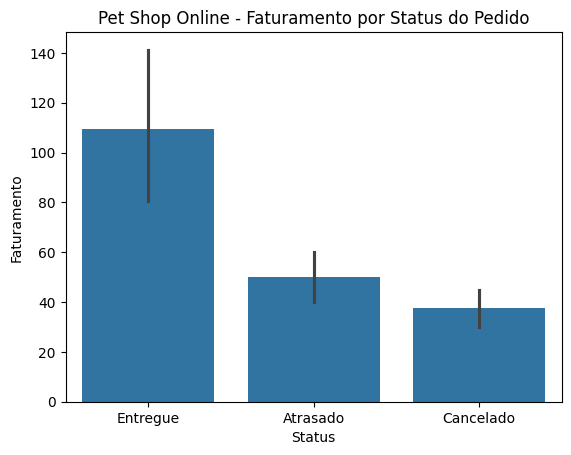

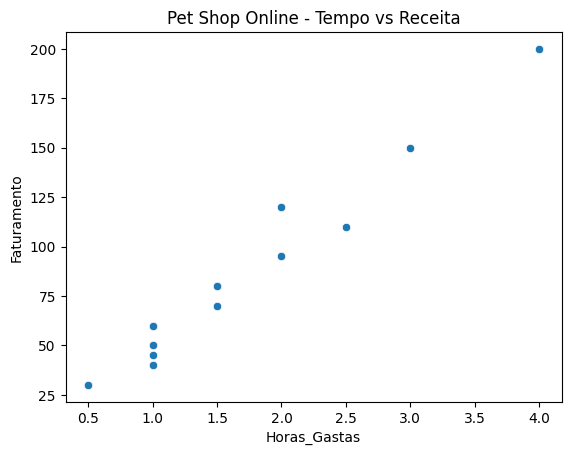

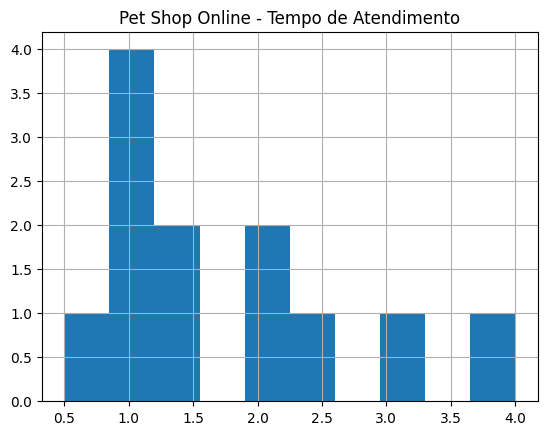

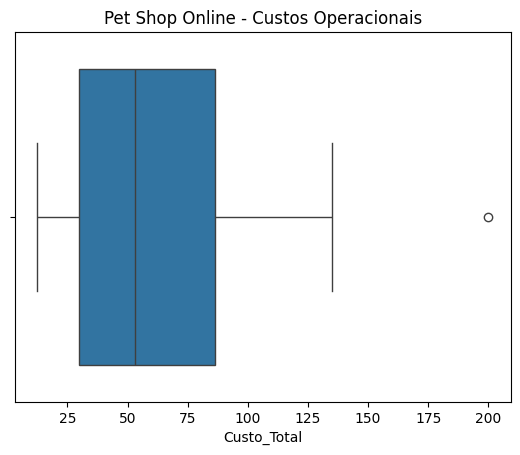

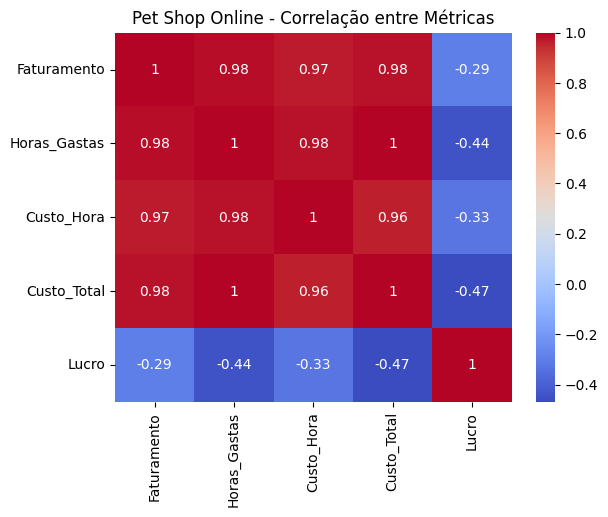

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Base Pet Shop Online
dados = {
    'Faturamento': [50, 120, 40, 80, 150, 30, 95, 60, 110, 70, 200, 45],
    'Horas_Gastas': [1, 2, 1, 1.5, 3, 0.5, 2, 1, 2.5, 1.5, 4, 1],
    'Custo_Hora': [30, 40, 30, 35, 45, 25, 38, 30, 42, 36, 50, 28],
    'Status': ['Entregue', 'Entregue', 'Atrasado', 'Entregue',
               'Entregue', 'Cancelado', 'Entregue', 'Atrasado',
               'Entregue', 'Entregue', 'Entregue', 'Cancelado']
}

df = pd.DataFrame(dados)

# Features
df['Custo_Total'] = df['Horas_Gastas'] * df['Custo_Hora']
df['Lucro'] = df['Faturamento'] - df['Custo_Total']

# 1. Faturamento por Status
sns.barplot(x='Status', y='Faturamento', data=df)
plt.title('Pet Shop Online - Faturamento por Status do Pedido')
plt.show()

# 2. Horas vs Faturamento
sns.scatterplot(x='Horas_Gastas', y='Faturamento', data=df)
plt.title('Pet Shop Online - Tempo vs Receita')
plt.show()

# 3. Distribuição de horas
df['Horas_Gastas'].hist(bins=10)
plt.title('Pet Shop Online - Tempo de Atendimento')
plt.show()

# 4. Outliers de custo
sns.boxplot(x=df['Custo_Total'])
plt.title('Pet Shop Online - Custos Operacionais')
plt.show()

# 5. Correlação
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Pet Shop Online - Correlação entre Métricas')
plt.show()